In [1]:
from google.colab import files
uploaded = files.upload ()

Saving PSCompPars_2026.03.13_07.09.46.csv to PSCompPars_2026.03.13_07.09.46.csv


In [2]:
import pandas as pd

df = pd.read_csv("PSCompPars_2026.03.13_07.09.46.csv", comment="#")
df.head ()


,pl_name,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,...,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_metratio,rastr,ra,decstr,dec
0,11 Com b,2,1,Radial Velocity,2007.0,Xinglong Station,323.21000,0.06000,-0.05000,0.0,...,G8 III,4874.0,NaN,NaN,0.0,[Fe/H],12h20m42.91s,185.178779,+17d47m35.71s,17.793252
1,11 UMi b,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,516.21997,3.20000,-3.20000,0.0,...,K4 III,4213.0,46.0,-46.0,0.0,[Fe/H],15h17m05.90s,229.274595,+71d49m26.19s,71.823943
2,14 And b,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,186.76000,0.11000,-0.12000,0.0,...,K0 III,4888.0,NaN,NaN,0.0,[Fe/H],23h31m17.80s,352.824150,+39d14m09.01s,39.235837
3,14 Her b,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,1765.03890,1.67709,-1.87256,0.0,...,K0V,5338.0,25.0,-25.0,0.0,[Fe/H],16h10m24.50s,242.602101,+43d48m58.90s,43.816362
4,16 Cyg B b,3,1,Radial Velocity,1996.0,Multiple Observatories,798.50000,1.00000,-1.00000,0.0,...,G3 V,5750.0,8.0,-8.0,0.0,[Fe/H],19h41m51.75s,295.465642,+50d31m00.57s,50.516824


In [3]:
print(df.columns)

Index(['pl_name', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year',
       'disc_facility', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2',
       'pl_orbperlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim',
       'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse',
       'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj',
       'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'st_spectype', 'st_teff', 'st_tefferr1',
       'st_tefferr2', 'st_tefflim', 'st_metratio', 'rastr', 'ra', 'decstr',
       'dec'],
      dtype='object')


In [4]:
hot_jupiter = df[
    (df["pl_bmassj"]>0.3)&
    (df["pl_orbper"]<10)
]

print(len(hot_jupiter))

681


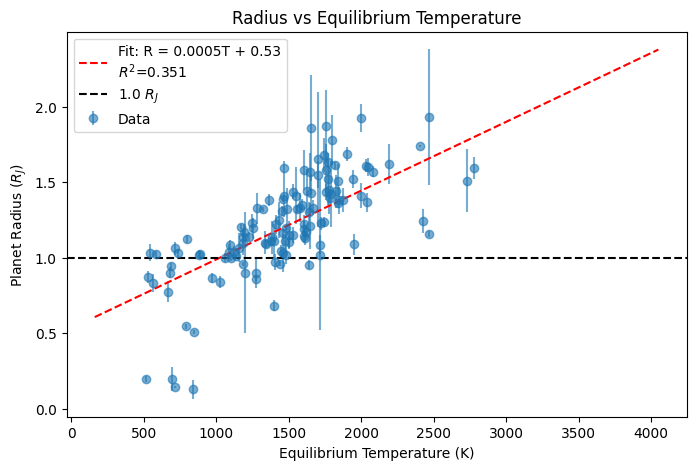

In [9]:
import numpy as np
from sklearn.metrics import r2_score

x = hot_jupiter['pl_eqt']
y = hot_jupiter['pl_radj']
yerr_up = hot_jupiter['pl_radjerr1']
yerr_down = np.abs(hot_jupiter['pl_radjerr2'])

mask = (~np.isnan(x))&(~np.isnan(y))&(~np.isnan(yerr_up))&(~np.isnan(yerr_down))

x=x[mask]
y=y[mask]
yerr=(yerr_up[mask]+yerr_down[mask])/2

plt.figure(figsize=(8,5))

m, b = np.polyfit(x, y, 1)
y_fit = m*x + b

r2 = r2_score(y, y_fit)

plt.errorbar(
    x[::5], y[::5],
    yerr=yerr[::5],
    fmt='o', alpha=0.6, label='Data'
)

x_sorted = np.sort(x)
plt.plot(
    x_sorted,
    m*x_sorted+b,
    "r--",
    label=f"Fit: R = {m:.4f}T + {b:.2f}\n$R^2$={r2:.3f}"
)

plt.axhline(1.0, color="black", linestyle="--", label="1.0 $R_J$")

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius ($R_J$)")
plt.title("Radius vs Equilibrium Temperature")

plt.legend()
plt.show()

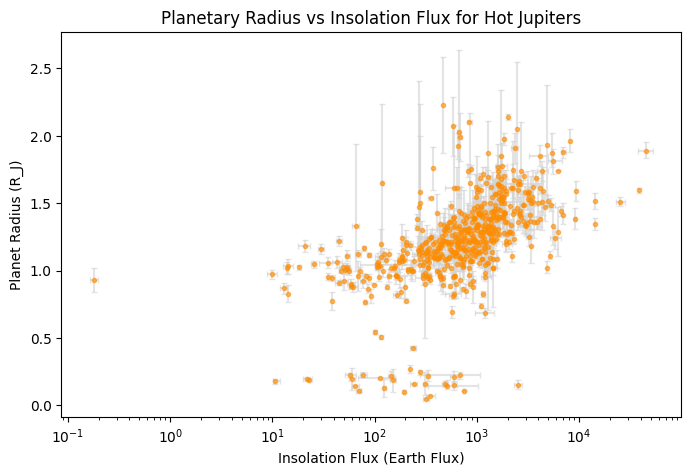

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.errorbar(
    hot_jupiter["pl_insol"],
    hot_jupiter["pl_radj"],
    yerr=[np.abs(hot_jupiter['pl_radjerr2']), hot_jupiter['pl_radjerr1']],
    xerr=[np.abs(hot_jupiter['pl_insolerr2']), hot_jupiter['pl_insolerr1']],
    fmt='o',
    markersize=3,
    color='darkorange',
    ecolor='lightgray',
    capsize=2,
    alpha=0.6
)

plt.xscale('log')
plt.xlabel("Insolation Flux (Earth Flux)")
plt.ylabel("Planet Radius (R_J)")
plt.title("Planetary Radius vs Insolation Flux for Hot Jupiters")

plt.show()

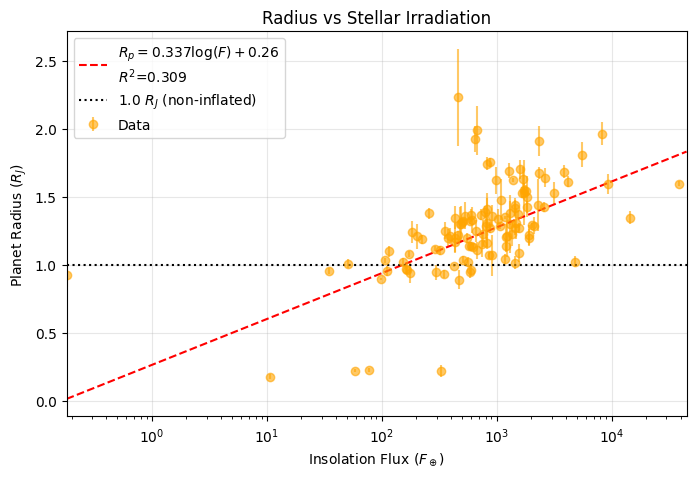

In [16]:
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

x = hot_jupiter["pl_insol"]
y = hot_jupiter["pl_radj"]
yerr_up = hot_jupiter['pl_radjerr1']
yerr_down = np.abs(hot_jupiter['pl_radjerr2'])

mask = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isnan(yerr_up)) & (~np.isnan(yerr_down)) & (x > 0)

x = x[mask]
y = y[mask]

yerr = (yerr_up[mask] + yerr_down[mask])/2

x_log = np.log10(x)


m, b = np.polyfit(x_log, y, 1)
y_fit = m*x_log + b

r2 = r2_score(y, y_fit)

plt.figure(figsize=(8,5))

plt.errorbar(
    x[::5], y[::5],
    yerr=yerr[::5],
    fmt='o', alpha=0.6, label='Data', color='orange'
)

x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
y_line = m*np.log10(x_line) + b

plt.plot(
    x_line, y_line,
    "r--",
    label=f"$R_p = {m:.3f}\\log(F) + {b:.2f}$\n$R^2$={r2:.3f}"
)

plt.xscale("log")

plt.axhline(1.0, color='black',linestyle=':', label='1.0 $R_J$ (non-inflated)')

plt.xlim(x.min(), x.max())
plt.grid(alpha=0.3)
plt.xlabel("Insolation Flux ($F_\\oplus$)")
plt.ylabel("Planet Radius ($R_J$)")
plt.title("Radius vs Stellar Irradiation")

plt.legend()
plt.show()

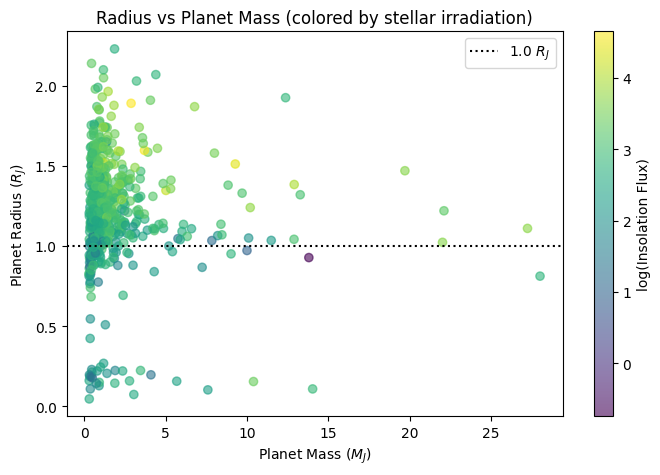

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = hot_jupiter["pl_bmassj"]
y = hot_jupiter["pl_radj"]
flux = hot_jupiter['pl_insol']

mask = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isnan(flux)) & (flux >0)

x = x[mask]
y = y[mask]
flux = flux[mask]

plt.figure(figsize=(8,5))

sc = plt.scatter(x, y, c=np.log10(flux), cmap='viridis', alpha=0.6)

plt.colorbar(sc, label="log(Insolation Flux)")


plt.xlabel("Planet Mass ($M_J$)")
plt.ylabel("Planet Radius ($R_J$)")
plt.title("Radius vs Planet Mass (colored by stellar irradiation)")

plt.axhline(1.0, color='black', linestyle=':', label='1.0 $R_J$')

plt.legend()
plt.show()

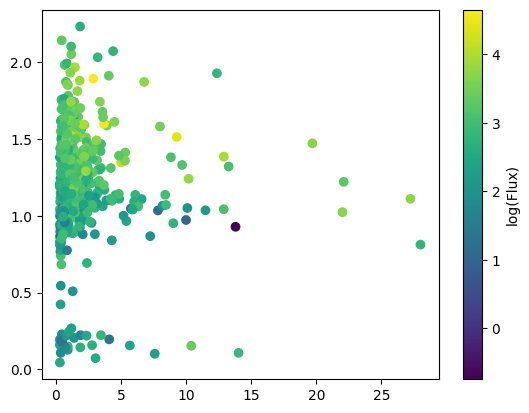

In [18]:
plt.scatter(x, y, c=np.log10(hot_jupiter["pl_insol"][mask]), cmap='viridis')
plt.colorbar(label="log(Flux)")

In [19]:
fit_data = hot_jupiter[["pl_eqt","pl_radj"]].dropna()

In [20]:
import numpy as np

z = np.polyfit(fit_data["pl_eqt"],fit_data["pl_radj"],1)
p = np.poly1d(z)


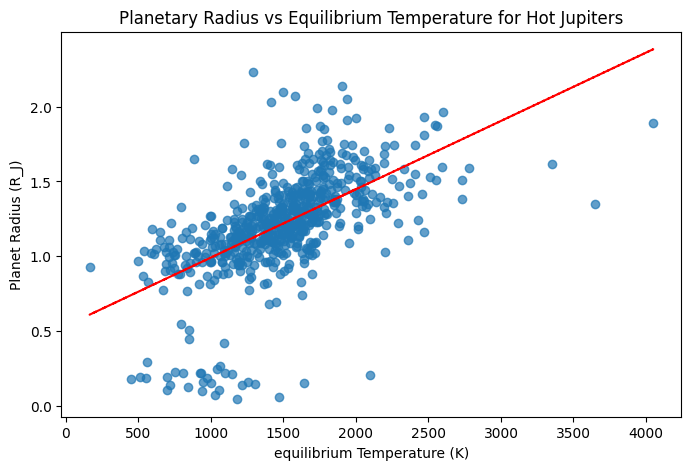

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    hot_jupiter["pl_eqt"],
    hot_jupiter["pl_radj"],
    alpha=0.7
)

plt.plot(
    fit_data["pl_eqt"],
    p(fit_data['pl_eqt']),
    "r--"
)

plt.xlabel("equilibrium Temperature (K)")
plt.ylabel("Planet Radius (R_J)")
plt.title("Planetary Radius vs Equilibrium Temperature for Hot Jupiters")

plt.show()


In [22]:
fit_data = hot_jupiter[["pl_insol","pl_radj"]].dropna()

import numpy as np

z = np.polyfit(fit_data["pl_insol"],fit_data["pl_radj"],1)
p = np.poly1d(z)



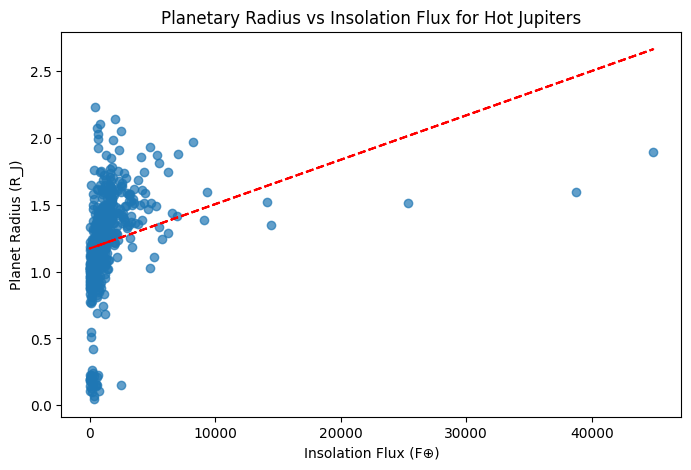

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    hot_jupiter["pl_insol"],
    hot_jupiter["pl_radj"],
    alpha=0.7
)

plt.plot(
    fit_data["pl_insol"],
    p(fit_data['pl_insol']),
    "r--"
)

plt.xlabel("Insolation Flux (F⊕)")
plt.ylabel("Planet Radius (R_J)")
plt.title("Planetary Radius vs Insolation Flux for Hot Jupiters")

plt.show()


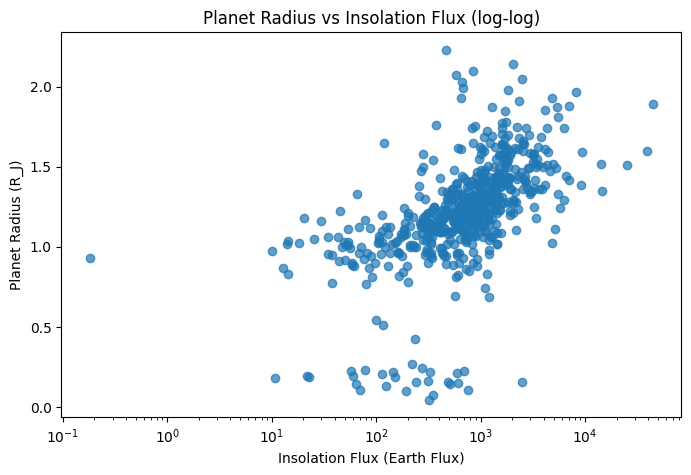

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    hot_jupiter["pl_insol"],
    hot_jupiter["pl_radj"],
    alpha=0.7
)

plt.xscale("log")

plt.xlabel ("Insolation Flux (Earth Flux)")
plt.ylabel ("Planet Radius (R_J)")
plt.title("Planet Radius vs Insolation Flux (log-log)")

plt.show()

In [25]:
import numpy as np

x=hot_jupiter["pl_insol"]
y=hot_jupiter["pl_radj"]

mask=(x>0)&(y>0)
x=x[mask]
y=y[mask]

logx=np.log10(x)
logy=np.log10(y)

m,b=np.polyfit(logx,logy,1)

x_fit = np.linspace(min(x),max(x),100)
y_fit = 10**(m*np.log10(x_fit)+b)


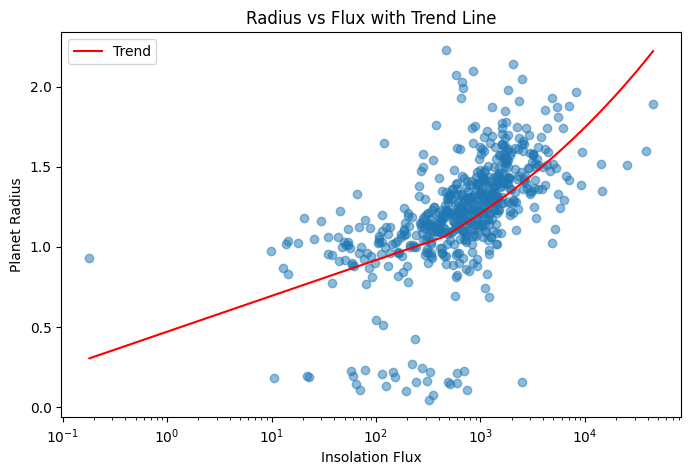

0.16028813627687297
Slope(alpha) = 0.160


In [26]:
plt. figure (figsize=(8,5))

plt.scatter(x,y, alpha=0.5)

plt.plot(x_fit, y_fit, color="red", label="Trend")

plt.xscale("log")


plt.xlabel("Insolation Flux")
plt.ylabel("Planet Radius")
plt.title("Radius vs Flux with Trend Line")

plt.legend()
plt.show()


print(m)

print(f"Slope(alpha) = {m:.3f}")


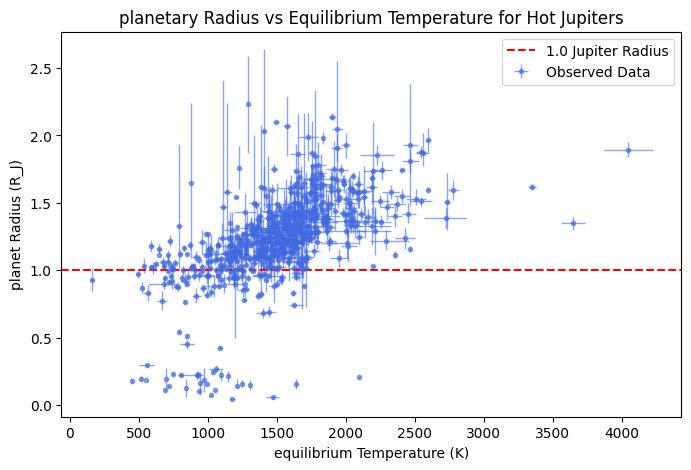

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.errorbar(
    hot_jupiter["pl_eqt"],
    hot_jupiter["pl_radj"],
    yerr=[np.abs(hot_jupiter['pl_radjerr2']), hot_jupiter['pl_radjerr1']],
    xerr=[np.abs(hot_jupiter['pl_eqterr2']), hot_jupiter['pl_eqterr1']],
    fmt='o',
    markersize=3,
    color='royalblue',
    elinewidth=1,
    capsize=0,
    alpha=0.6,
    label='Observed Data'
)

plt.axhline(y=1.0, color='r', linestyle='--', label='1.0 Jupiter Radius')
plt.xlabel ("equilibrium Temperature (K)")
plt.ylabel ("planet Radius (R_J)")
plt.title ("planetary Radius vs Equilibrium Temperature for Hot Jupiters")
plt.legend()
plt.show()

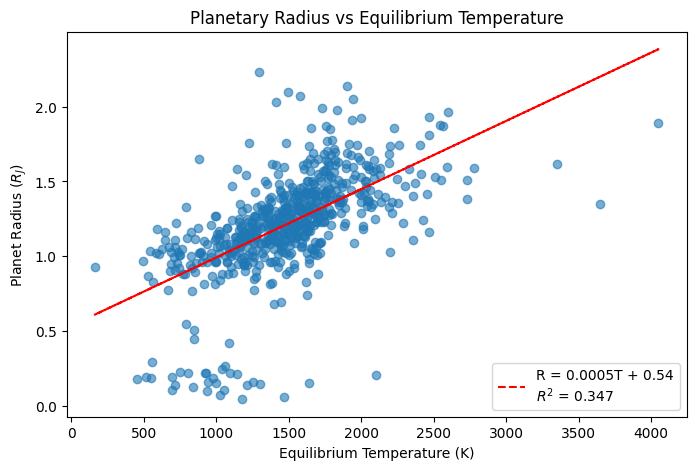

In [28]:
import numpy as np
from sklearn.metrics import r2_score

x = hot_jupiter["pl_eqt"]
y = hot_jupiter["pl_radj"]

# 去掉NaN
mask = (~np.isnan(x)) & (~np.isnan(y))
x = x[mask]
y = y[mask]

# 拟合
m, b = np.polyfit(x, y, 1)
y_fit = m*x + b

# R²
r2 = r2_score(y, y_fit)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6)

plt.plot(x, y_fit, "r--",
         label=f"R = {m:.4f}T + {b:.2f}\n$R^2$ = {r2:.3f}")

plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Planet Radius ($R_J$)")
plt.title("Planetary Radius vs Equilibrium Temperature")

plt.legend()
plt.show()


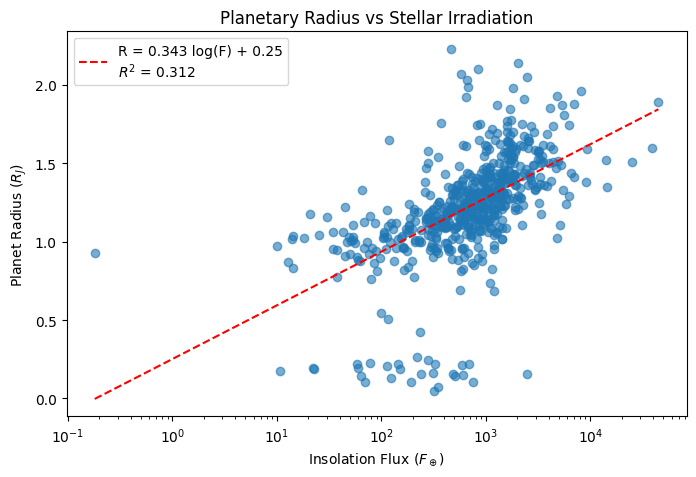

In [29]:
x = hot_jupiter["pl_insol"]
y = hot_jupiter["pl_radj"]

mask = (~np.isnan(x)) & (~np.isnan(y)) & (x > 0)
x = x[mask]
y = y[mask]

# log transform
x_log = np.log10(x)

# 拟合
m, b = np.polyfit(x_log, y, 1)
y_fit = m*x_log + b

# R²
r2 = r2_score(y, y_fit)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.6)

# 用平滑曲线画
x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
y_line = m*np.log10(x_line) + b

plt.plot(x_line, y_line, "r--",
         label=f"R = {m:.3f} log(F) + {b:.2f}\n$R^2$ = {r2:.3f}")

plt.xscale("log")

plt.xlabel("Insolation Flux ($F_\\oplus$)")
plt.ylabel("Planet Radius ($R_J$)")
plt.title("Planetary Radius vs Stellar Irradiation")

plt.legend()
plt.show()
